In [1]:
# Cell 1: Imports
import os
import glob
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
%matplotlib inline



In [2]:
# Cell 2: Locate all your events files
# Point this to the directory (or directories) where your runs are stored:
base_log_dir = "/home/mike/DPhil/risk_aware_manip_docker/IsaacLab/experiment_logs/depth_tensorboard"
# If you have subfolders per run, glob for them:
pattern = os.path.join(base_log_dir, "events.out.tfevents*")
event_paths = sorted(glob.glob(pattern))

# Map either the basename or full path to the legend label you want:
file_to_label = {
    # basename: label
    "events.out.tfevents.1741974119.haku.52428.0": "Depth",
    "events.out.tfevents.1741974200.haku.261314.0": "Scandots",
    # you can also use absolute paths if you prefer:
    # "/full/path/to/events.out.tfevents.xxxx": "Model C"
}

# Build a dict: path → legend label
runs = {
    p: file_to_label[os.path.basename(p)]
    for p in event_paths
    if os.path.basename(p) in file_to_label
}

print("Plotting these runs:")
for path, lbl in runs.items():
    print(f"  {lbl:<10s} ← {path}")

Plotting these runs:
  Depth      ← /home/mike/DPhil/risk_aware_manip_docker/IsaacLab/experiment_logs/depth_tensorboard/events.out.tfevents.1741974119.haku.52428.0
  Scandots   ← /home/mike/DPhil/risk_aware_manip_docker/IsaacLab/experiment_logs/depth_tensorboard/events.out.tfevents.1741974200.haku.261314.0


In [3]:
# Cell 3: Load an EventAccumulator per run, keyed by label
accumulators = {}
for path, label in runs.items():
    ea = event_accumulator.EventAccumulator(path,
        size_guidance={event_accumulator.SCALARS: 0})
    ea.Reload()
    accumulators[label] = ea




In [4]:
# Cell 4: Extract chosen tag across runs
x_tag = "Train/total_env_steps"
y_tag = "Curriculum/goal_levels"  # ← pick one from common_tags
data = {}
for label, ea in accumulators.items():
    # Build step→value maps
    xs = {e.step: e.value for e in ea.Scalars(x_tag)}
    ys = {e.step: e.value for e in ea.Scalars(y_tag)}
    # Find common steps and sort them
    common_steps = sorted(set(xs) & set(ys))
    if not common_steps:
        print(f"Warning: no overlapping steps for '{label}'")
        continue
    x_vals = [xs[s] for s in common_steps]
    y_vals = [ys[s] for s in common_steps]
    data[label] = (x_vals, y_vals)



Plotting Depth: 2255 points
Plotting Scandots: 1271 points


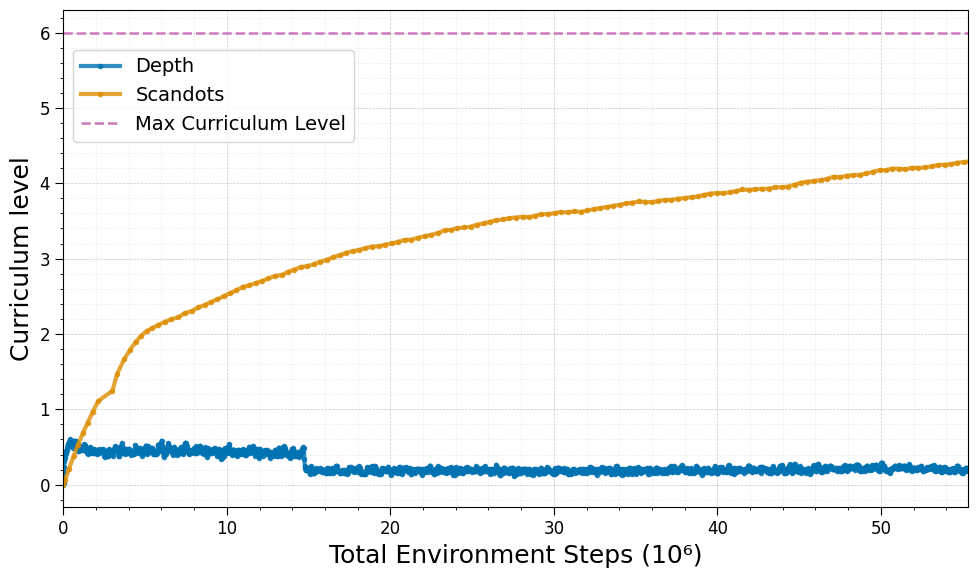

In [12]:
# Cell 5: Scatter‐plot each run’s (x,y) and set x‐limits based on one run’s max x
import matplotlib.pyplot as plt


plt.rcParams.update({
  'font.size':       14,
  'axes.labelsize':  16,
  'axes.titlesize':  16,
  'lines.linewidth': 1.8,
  'legend.fontsize': 12,
})

# Choose which run to base your x‐limit on (must be one of your data.keys())
ref_label = "Depth"   # ← replace with the label for your reference file

# Compute the max x‐value for that run
if ref_label in data:
    max_x = max(data[ref_label][0])
else:
    raise ValueError(f"Reference run '{ref_label}' not found in data keys: {list(data.keys())}")

# Cell 5: Plot with the custom legend labels
colours = {
    "Depth": "#0173b2", # 
    "Scandots": "#de8f05",
}
plt.figure(figsize=(10, 6))
for label, (xv, yv) in data.items():
    print(f"Plotting {label}: {len(xv)} points")
    plt.plot(
        xv, yv,
        label=label,
        color=colours[label],
        linewidth=3,           # thicker lines
        marker='o',            # add markers at each point
        markersize=3,          # reasonable marker size
        alpha=0.8              # slight transparency to reduce visual clutter
    )
    
plt.xlim(0, max_x)

# Plot a horizontal line at y=6, with label "Max Curriculum Level"
plt.axhline(y=6, color='#cc78bc', linestyle='--', label="Max Curriculum Level")

# plt.title(f"Comparison of '{tag}' across configured runs")
plt.xlabel("Total Environment Steps", fontsize=18)
plt.ylabel("Curriculum level", fontsize=18)
plt.grid(which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.4)
plt.minorticks_on()
# Tweak tick parameters for better readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, pos: f"{int(x/1e6)}"
))

# label accordingly
plt.xlabel("Total Environment Steps (10\u2076)", fontsize=18)
plt.ylabel("Curriculum level",                fontsize=18)
plt.tick_params(axis='both', which='major', length=6)
plt.legend(loc="upper left", fontsize=14, frameon=True, bbox_to_anchor=(0.0, 0.94))
plt.tight_layout()
plt.savefig("depth_curriculum_plot.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight")
plt.show()


In [ ]:
plt.savefig("depth_curriculum_plot.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>